# Logical Fallacy Detection
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa

**Citation:**
Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Import Libraries

In [ ]:
import json
import re
import os
import numpy as np
import pandas as pd

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

## 1. Load Dataset

In [2]:
import os
import json
import pandas as pd

KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'

if os.path.exists(KAGGLE_PATH):
    DATA_DIR = KAGGLE_PATH
    print(f"Running on Kaggle (dataset: {DATA_DIR})")
else:
    DATA_DIR = 'data'   
    print("Running locally")

# Construct the full path to train.json
file_path = os.path.join(DATA_DIR, 'train.json')

# Check if file exists before trying to open it to prevent cryptic errors
if not os.path.exists(file_path):
    print(f"Error: Could not find train.json at {file_path}")
else:
    # Load the train.json dataset
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
        
    # Extract all comments from every news article
    records = []
    for article in raw_data:
        for comment in article['comments']:
            records.append({
                'comment_id': comment['id'],
                'news_id': comment['news_id'],
                'fallacy': comment['fallacy'],
                'comment': comment['comment']
            })

    df = pd.DataFrame(records)

    print(f"Total komentar: {len(df)}")
    print(f"\nDistribusi label fallacy:")
    print(df['fallacy'].value_counts())
    print(f"\n--- Sample Data (Teks Mentah) ---")
    
    # Use display() instead of print() for a much cleaner table output in Kaggle notebooks
    display(df.head(10))

Running on Kaggle (dataset: /kaggle/input/datasets/aristelcrowley/cocolofa)
Total komentar: 5370

Distribusi label fallacy:
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64

--- Sample Data (Teks Mentah) ---


,comment_id,news_id,fallacy,comment
0,5584,262,none,Lack of transparency in government isn't unexp...
1,5582,262,appeal to authority,While the issues discussed here should be addr...
2,5583,262,none,The excuse that Brazilian municipalities do no...
3,6183,262,none,This is what's to be expected of developing an...
4,6182,262,appeal to tradition,"Sad to say, I have to agree with you. Rulers c..."
5,6184,262,none,Why doesn't the Brazilian federal government s...
6,6782,262,appeal to worse problems,At least they have a set up for it. In some co...
7,6783,262,hasty generalization,If these people can't even manage doing someth...
8,6784,262,appeal to tradition,I completely agree with you! There have alway...
9,10082,262,slippery slope,The argument that people should have access to...


## 2. Text Cleaning

In [3]:
def clean_text(text):
    """Membersihkan teks mentah."""
    text = text.lower()                                    # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)           # hapus URL
    text = re.sub(r'<[^>]+>', '', text)                    # hapus HTML tags
    text = re.sub(r'@\w+', '', text)                       # hapus mentions
    text = re.sub(r'#\w+', '', text)                       # hapus hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)                # hapus angka & special chars
    text = re.sub(r'\s+', ' ', text).strip()               # hapus spasi berlebih
    return text

df['cleaned'] = df['comment'].apply(clean_text)

print("--- Contoh Sebelum & Sesudah Cleaning ---")
for i in range(3):
    print(f"\n[BEFORE]: {df['comment'].iloc[i][:120]}...")
    print(f"[AFTER ]: {df['cleaned'].iloc[i][:120]}...")

--- Contoh Sebelum & Sesudah Cleaning ---

[BEFORE]: Lack of transparency in government isn't unexpected.  No one likes to be under scrutiny,  especially not those with powe...
[AFTER ]: lack of transparency in government isnt unexpected no one likes to be under scrutiny especially not those with power tra...

[BEFORE]: While the issues discussed here should be addressed, there need to be priorities. The authorities of the country probabl...
[AFTER ]: while the issues discussed here should be addressed there need to be priorities the authorities of the country probably ...

[BEFORE]: The excuse that Brazilian municipalities do not have the funds to handle the public service requests does not hold water...
[AFTER ]: the excuse that brazilian municipalities do not have the funds to handle the public service requests does not hold water...


## 3. Tokenisasi

In [4]:
df['tokens'] = df['cleaned'].apply(word_tokenize)

print("--- Contoh Hasil Tokenisasi ---")
for i in range(3):
    print(f"\n[CLEANED ]: {df['cleaned'].iloc[i][:100]}...")
    print(f"[TOKENS  ]: {df['tokens'].iloc[i][:15]}...")
    print(f"Jumlah token: {len(df['tokens'].iloc[i])}")

--- Contoh Hasil Tokenisasi ---

[CLEANED ]: lack of transparency in government isnt unexpected no one likes to be under scrutiny especially not ...
[TOKENS  ]: ['lack', 'of', 'transparency', 'in', 'government', 'isnt', 'unexpected', 'no', 'one', 'likes', 'to', 'be', 'under', 'scrutiny', 'especially']...
Jumlah token: 64

[CLEANED ]: while the issues discussed here should be addressed there need to be priorities the authorities of t...
[TOKENS  ]: ['while', 'the', 'issues', 'discussed', 'here', 'should', 'be', 'addressed', 'there', 'need', 'to', 'be', 'priorities', 'the', 'authorities']...
Jumlah token: 55

[CLEANED ]: the excuse that brazilian municipalities do not have the funds to handle the public service requests...
[TOKENS  ]: ['the', 'excuse', 'that', 'brazilian', 'municipalities', 'do', 'not', 'have', 'the', 'funds', 'to', 'handle', 'the', 'public', 'service']...
Jumlah token: 93


## 4. Stopword Removal & Lemmatization

> Dipilih **lemmatization** daripada stemming karena menghasilkan kata dasar yang valid secara bahasa, lebih cocok untuk tugas deteksi fallacy yang membutuhkan pemahaman makna.

In [5]:
# Words that are NLTK stopwords but are KEY fallacy indicators — we keep these
# "everyone/always/never/must/should/only/just" → crucial for detecting fallacy types
fallacy_indicators = {
    'everyone', 'always', 'never', 'must', 'should', 'all', 'every',
    'only', 'just', 'no', 'nothing', 'everything', 'most', 'any',
    'either', 'or', 'neither', 'nor', 'both', 'very', 'too',
}
stop_words = set(stopwords.words('english')) - fallacy_indicators
print(f"Stopwords: {len(set(stopwords.words('english')))} total → {len(stop_words)} after keeping {len(fallacy_indicators)} fallacy indicators")

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Hapus stopwords (kecuali fallacy indicators) dan lemmatize setiap token."""
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)

# Gabungkan kembali menjadi string untuk keperluan TF-IDF
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))

print("\n--- Contoh Hasil Lemmatization ---")
for i in range(3):
    print(f"\n[TOKENS     ]: {df['tokens'].iloc[i][:12]}...")
    print(f"[LEMMATIZED ]: {df['lemmatized'].iloc[i][:12]}...")
    print(f"Jumlah token sebelum: {len(df['tokens'].iloc[i])} → sesudah: {len(df['lemmatized'].iloc[i])}")

Stopwords: 198 total → 186 after keeping 21 fallacy indicators

--- Contoh Hasil Lemmatization ---

[TOKENS     ]: ['lack', 'of', 'transparency', 'in', 'government', 'isnt', 'unexpected', 'no', 'one', 'likes', 'to', 'be']...
[LEMMATIZED ]: ['lack', 'transparency', 'government', 'isnt', 'unexpected', 'one', 'like', 'scrutiny', 'especially', 'power', 'transparency', 'law']...
Jumlah token sebelum: 64 → sesudah: 32

[TOKENS     ]: ['while', 'the', 'issues', 'discussed', 'here', 'should', 'be', 'addressed', 'there', 'need', 'to', 'be']...
[LEMMATIZED ]: ['issue', 'discussed', 'should', 'addressed', 'need', 'priority', 'authority', 'country', 'probably', 'know', 'whats', 'important']...
Jumlah token sebelum: 55 → sesudah: 31

[TOKENS     ]: ['the', 'excuse', 'that', 'brazilian', 'municipalities', 'do', 'not', 'have', 'the', 'funds', 'to', 'handle']...
[LEMMATIZED ]: ['excuse', 'brazilian', 'municipality', 'fund', 'handle', 'public', 'service', 'request', 'hold', 'water', 'evident', 'fact'].

## 5. Representasi Teks

### a. TF-IDF (Term Frequency–Inverse Document Frequency) 

**TF-IDF** mengukur seberapa penting suatu kata dalam sebuah dokumen relatif terhadap seluruh korpus.
- Cocok sebagai baseline karena menangkap pola kata kunci yang sering muncul di tiap jenis fallacy.
- Menghasilkan sparse matrix berdimensi tinggi.

In [6]:
# TF-IDF Vectorization — optimized for fallacy detection
# sublinear_tf=True → log(1+tf) dampens high-frequency term dominance
# ngram_range=(1,3) → captures longer fallacy-indicating phrases like "always been done", "everyone knows that"
# min_df=2 → removes ultra-rare terms that cause memorization
# max_df=0.95 → removes terms appearing in >95% of docs (noise)
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} dokumen, {tfidf_matrix.shape[1]} fitur")

# Tampilkan top fitur TF-IDF untuk beberapa sampel
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nContoh 20 fitur (kata/bigram/trigram): {list(feature_names[:20])}")

# Konversi ke DataFrame untuk preview
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

print(f"\n--- Preview TF-IDF Matrix (5 dokumen pertama, 10 fitur pertama) ---")
tfidf_df.iloc[:5, :10]

TF-IDF Matrix Shape: (5370, 8000)
  → 5370 dokumen, 8000 fitur

Contoh 20 fitur (kata/bigram/trigram): ['abandon', 'abandoned', 'abhorrent', 'ability', 'able', 'able access', 'able express', 'able get', 'able make', 'able say', 'able speak', 'able speak mind', 'able use', 'abroad', 'absolute', 'absolutely', 'absurd', 'abuse', 'abuse power', 'abused']

--- Preview TF-IDF Matrix (5 dokumen pertama, 10 fitur pertama) ---


,abandon,abandoned,abhorrent,ability,able,able access,able express,able get,able make,able say
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### b. Word2Vec
**Word2Vec** mempelajari embedding vektor untuk setiap kata berdasarkan konteks kemunculannya.
- Menangkap hubungan semantik antar kata (misal: "authority" dekat dengan "expert", "tradition" dekat dengan "culture").
- Representasi dokumen diperoleh dengan merata-ratakan vektor semua kata dalam dokumen.
- Menghasilkan dense vector berdimensi tetap untuk setiap dokumen.

In [ ]:
# Train Word2Vec pada corpus lemmatized
w2v_model = Word2Vec(
    sentences=df['lemmatized'].tolist(),
    vector_size=100,    # dimensi embedding
    window=5,           # context window
    min_count=2,        # abaikan kata yang muncul < 2 kali
    workers=4,
    epochs=20,
    sg=1                # skip-gram (lebih baik untuk dataset kecil)
)

print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector dimension: {w2v_model.wv.vector_size}")

# Contoh kata-kata mirip
for word in ['government', 'freedom', 'tradition']:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nKata mirip dengan '{word}':")
        for w, score in similar:
            print(f"  {w}: {score:.4f}")

Vocabulary size: 6652
Vector dimension: 150
Documents trained: 5370

Kata mirip dengan 'government':
  people: 0.6102
  should: 0.5356
  need: 0.5291
  all: 0.5224
  just: 0.5137

Kata mirip dengan 'freedom':
  speech: 0.6147
  expression: 0.5945
  inviolate: 0.4771
  press: 0.4744
  right: 0.4593

Kata mirip dengan 'tradition':
  patrimony: 0.4181
  deity: 0.4092
  deviate: 0.4009
  forefather: 0.3938
  deeprooted: 0.3934


In [ ]:
def document_vector(tokens, model):
    """Hitung rata-rata Word2Vec vector untuk seluruh token dalam dokumen."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# Buat document vectors untuk semua komentar
w2v_vectors = np.array([
    document_vector(tokens, w2v_model) for tokens in df['lemmatized']
])

w2v_df = pd.DataFrame(
    w2v_vectors,
    columns=[f'w2v_dim_{i}' for i in range(w2v_model.wv.vector_size)]
)

print(f"Word2Vec Document Matrix Shape: {w2v_vectors.shape}")
print(f"  → {w2v_vectors.shape[0]} dokumen, {w2v_vectors.shape[1]} dimensi")
print(f"\n--- Preview Word2Vec Document Vectors (5 dokumen pertama, 10 dimensi pertama) ---")
w2v_df.iloc[:5, :10]

Doc2Vec Document Matrix Shape: (5370, 150)
  → 5370 dokumen, 150 dimensi

--- Preview Doc2Vec Document Vectors (5 dokumen pertama, 10 dimensi pertama) ---


,d2v_dim_0,d2v_dim_1,d2v_dim_2,d2v_dim_3,d2v_dim_4,d2v_dim_5,d2v_dim_6,d2v_dim_7,d2v_dim_8,d2v_dim_9
0,0.192816,-0.449080,0.119880,0.082560,0.370120,-0.296563,-0.160616,-0.093665,0.195896,0.009413
1,0.091112,0.235213,-0.112945,-0.134764,-0.122559,0.177800,-0.265546,-0.155874,0.425362,-0.199001
2,0.207899,-0.047909,0.815865,-0.021866,-0.751595,-0.021110,-0.082851,-0.250275,0.122914,0.311728
3,-0.409536,-0.358891,0.044338,-0.142139,-0.655202,-0.072029,0.095330,0.103556,0.428593,-0.033960
4,-0.380789,-0.348219,0.172918,-0.037974,0.134488,-0.145583,0.368314,-0.023883,0.126899,-0.223550


## 6. Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fallacy'])

print(f"Jumlah kelas: {len(label_encoder.classes_)}")
print(f"\nMapping label:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls} ({count} sampel)")

Jumlah kelas: 9

Mapping label:
  0 → appeal to authority (350 sampel)
  1 → appeal to majority (383 sampel)
  2 → appeal to nature (412 sampel)
  3 → appeal to tradition (401 sampel)
  4 → appeal to worse problems (421 sampel)
  5 → false dilemma (391 sampel)
  6 → hasty generalization (379 sampel)
  7 → none (2202 sampel)
  8 → slippery slope (431 sampel)


## 7. Model Training

Melatih beberapa model klasifikasi pada dua representasi fitur — **TF-IDF** dan **Word2Vec**:
- **Logistic Regression** — baseline linear yang kuat
- **Linear SVC** (with calibration) — SVM linear, efektif untuk teks berdimensi tinggi, di-wrap dengan CalibratedClassifierCV untuk mendapatkan probabilitas
- **Gradient Boosting** — ensemble boosting untuk performa optimal
- **SGD Classifier** — stochastic gradient descent dengan loss 'modified_huber' (mendukung probabilitas)

> **Perbaikan dari versi sebelumnya:**
> - **Stopwords penting dipertahankan** — kata seperti "everyone", "always", "must" krusial untuk deteksi fallacy
> - **CalibratedClassifierCV** pada SVC — menghasilkan probabilitas nyata, bukan skor mentah
> - **5-fold cross-validation** untuk estimasi generalisasi

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import copy, warnings
warnings.filterwarnings('ignore')

y_train = df['label'].values

# Model definitions — tuned for fallacy detection
model_defs = [
    ('Logistic Regression', LogisticRegression(
        max_iter=1000, C=1.5, random_state=42, class_weight='balanced', solver='lbfgs'
    )),
    ('Linear SVC (calibrated)', CalibratedClassifierCV(
        LinearSVC(max_iter=3000, C=1.0, random_state=42, class_weight='balanced'),
        cv=5, method='sigmoid'
    )),
    ('Gradient Boosting', GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        min_samples_leaf=5, subsample=0.8, random_state=42
    )),
    ('SGD Classifier', SGDClassifier(
        loss='modified_huber', class_weight='balanced',
        max_iter=1000, random_state=42, alpha=1e-4
    )),
]

def train_models(X, y, label, model_defs):
    """Train models and report train acc + 5-fold CV F1."""
    trained = {}
    for name, model in model_defs:
        m = copy.deepcopy(model)
        m.fit(X, y)
        trained[name] = m
        train_pred = m.predict(X)
        train_acc = accuracy_score(y, train_pred)
        cv_scores = cross_val_score(copy.deepcopy(model), X, y, cv=5, scoring='f1_weighted', n_jobs=-1)
        print(f"  {name:30s} → Train Acc: {train_acc:.4f} | CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    return trained

print("=" * 75)
print("  Training models on TF-IDF features")
print("=" * 75)
tfidf_models = train_models(tfidf_matrix, y_train, 'TF-IDF', model_defs)

print(f"\n{'=' * 75}")
print("  Training models on Word2Vec features")
print("=" * 75)
w2v_models = train_models(w2v_vectors, y_train, 'Word2Vec', model_defs)

print(f"\n✓ Total models trained: {len(tfidf_models) + len(w2v_models)}")

  Training models on TF-IDF features
  Logistic Regression            → Train Acc: 0.8683 | CV F1: 0.6674 ± 0.0121
  Linear SVC (calibrated)        → Train Acc: 0.9903 | CV F1: 0.6731 ± 0.0102
  Gradient Boosting              → Train Acc: 0.9998 | CV F1: 0.6346 ± 0.0128
  SGD Classifier                 → Train Acc: 0.9955 | CV F1: 0.6572 ± 0.0064

  Training models on Doc2Vec features
  Logistic Regression            → Train Acc: 0.5933 | CV F1: 0.4933 ± 0.0065
  Linear SVC (calibrated)        → Train Acc: 0.6845 | CV F1: 0.5907 ± 0.0119
  Gradient Boosting              → Train Acc: 1.0000 | CV F1: 0.5317 ± 0.0155
  SGD Classifier                 → Train Acc: 0.5380 | CV F1: 0.4829 ± 0.0353

✓ Total models trained: 8


## 8. Load & Preprocess Test Data

Memuat `test.json` dan menerapkan pipeline preprocessing yang sama (cleaning → tokenisasi → lemmatization → representasi fitur) agar konsisten dengan data latih.

In [ ]:
# Load test dataset
with open(os.path.join(DATA_DIR, 'test.json'), 'r', encoding='utf-8') as f:
    test_raw = json.load(f)

# Extract comments
test_records = []
for article in test_raw:
    for comment in article['comments']:
        test_records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df_test = pd.DataFrame(test_records)

print(f"Total komentar test: {len(df_test)}")
print(f"\nDistribusi label test:")
print(df_test['fallacy'].value_counts())

# Apply same preprocessing pipeline
df_test['cleaned'] = df_test['comment'].apply(clean_text)
df_test['tokens'] = df_test['cleaned'].apply(word_tokenize)
df_test['lemmatized'] = df_test['tokens'].apply(lemmatize_tokens)
df_test['processed_text'] = df_test['lemmatized'].apply(lambda x: ' '.join(x))

# Encode labels using the same encoder
df_test['label'] = label_encoder.transform(df_test['fallacy'])

# Transform to feature representations
X_test_tfidf = tfidf_vectorizer.transform(df_test['processed_text'])
X_test_w2v = np.array([
    document_vector(tokens, w2v_model) for tokens in df_test['lemmatized']
])
y_test = df_test['label'].values

print(f"\nTest TF-IDF shape:    {X_test_tfidf.shape}")
print(f"Test Word2Vec shape:  {X_test_w2v.shape}")

print(f"\n--- Sample Preprocessed Test Data ---")
df_test[['comment', 'cleaned', 'processed_text', 'fallacy']].head(5)

Total komentar test: 798

Distribusi label test:
fallacy
none                        317
slippery slope               78
appeal to worse problems     64
hasty generalization         60
appeal to tradition          59
appeal to majority           59
appeal to authority          56
appeal to nature             55
false dilemma                50
Name: count, dtype: int64

Test TF-IDF shape:   (798, 8000)
Test Doc2Vec shape:  (798, 150)

--- Sample Preprocessed Test Data ---


,comment,cleaned,processed_text,fallacy
0,Once you let them dictate rules against fairne...,once you let them dictate rules against fairne...,let dictate rule fairness continue problem onl...,slippery slope
1,Why can't the higher ups in journalism circles...,why cant the higher ups in journalism circles ...,cant higher ups journalism circle spain help w...,appeal to authority
2,Hopefully the country of Spain can provide wom...,hopefully the country of spain can provide wom...,hopefully country spain provide woman generali...,appeal to authority
3,I understand why you think having a rule that ...,i understand why you think having a rule that ...,understand think rule believe unfair would tro...,none
4,I am much more likely to trust the people in c...,i am much more likely to trust the people in c...,much likely trust people charge organization w...,appeal to authority


## 9. Evaluation on Test Set

Mengevaluasi semua model pada data test dan membandingkan performa menggunakan metrik:
- **Accuracy** — proporsi prediksi benar
- **Precision / Recall / F1 (weighted)** — mempertimbangkan ketidakseimbangan kelas
- **F1 (macro)** — rata-rata F1 per kelas tanpa bobot (lebih ketat untuk kelas minoritas)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

results = []

# Evaluate both feature sets
for feat_name, models_dict, X_feat in [
    ('TF-IDF', tfidf_models, X_test_tfidf),
    ('Word2Vec', w2v_models, X_test_w2v),
]:
    for name, model in models_dict.items():
        y_pred = model.predict(X_feat)
        acc = accuracy_score(y_test, y_pred)
        p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        results.append({
            'Model': name, 'Features': feat_name,
            'Accuracy': acc, 'Precision (weighted)': p,
            'Recall (weighted)': r, 'F1 (weighted)': f1, 'F1 (macro)': f1_macro,
        })

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1  # rank starting from 1

print("=" * 80)
print("  MODEL COMPARISON — Test Set Performance (Ranked by Weighted F1)")
print("=" * 80)
results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision (weighted)': '{:.4f}',
    'Recall (weighted)': '{:.4f}',
    'F1 (weighted)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens')

  MODEL COMPARISON — Test Set Performance (Ranked by Weighted F1)


,Model,Features,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro)
1,Logistic Regression,TF-IDF,0.6717,0.6772,0.6717,0.6698,0.6846
2,Linear SVC (calibrated),TF-IDF,0.6817,0.6886,0.6817,0.6679,0.6566
3,Gradient Boosting,TF-IDF,0.6654,0.6792,0.6654,0.6531,0.6471
4,SGD Classifier,TF-IDF,0.6541,0.6511,0.6541,0.6515,0.6531
5,Linear SVC (calibrated),Doc2Vec,0.5589,0.5625,0.5589,0.5251,0.4751
6,Logistic Regression,Doc2Vec,0.4662,0.5491,0.4662,0.4508,0.5021
7,Gradient Boosting,Doc2Vec,0.5075,0.5923,0.5075,0.4460,0.3684
8,SGD Classifier,Doc2Vec,0.4110,0.4764,0.4110,0.4048,0.4236


## 10. Best Model — Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Identify the best model
best_row = results_df.iloc[0]
best_name = best_row['Model']
best_features = best_row['Features']

print(f"Best Model: {best_name} ({best_features})")
print(f"Test Accuracy:     {best_row['Accuracy']:.4f}")
print(f"Test F1 (weighted): {best_row['F1 (weighted)']:.4f}")
print(f"Test F1 (macro):    {best_row['F1 (macro)']:.4f}")

# Get predictions from best model
if best_features == 'TF-IDF':
    best_model = tfidf_models[best_name]
    y_pred_best = best_model.predict(X_test_tfidf)
else:  # Word2Vec
    best_model = w2v_models[best_name]
    y_pred_best = best_model.predict(X_test_w2v)

print(f"\n{'=' * 70}")
print("  CLASSIFICATION REPORT (Best Model)")
print("=" * 70)
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Best Model: Logistic Regression (TF-IDF)
Test Accuracy:     0.6717
Test F1 (weighted): 0.6698
Test F1 (macro):    0.6846

  CLASSIFICATION REPORT (Best Model)
                          precision    recall  f1-score   support

     appeal to authority       0.62      0.64      0.63        56
      appeal to majority       0.73      0.86      0.79        59
        appeal to nature       0.82      0.93      0.87        55
     appeal to tradition       0.63      0.78      0.70        59
appeal to worse problems       0.70      0.75      0.72        64
           false dilemma       0.67      0.74      0.70        50
    hasty generalization       0.39      0.45      0.42        60
                    none       0.72      0.58      0.64       317
          slippery slope       0.65      0.72      0.68        78

                accuracy                           0.67       798
               macro avg       0.66      0.72      0.68       798
            weighted avg       0.68      0.67  

## 11. Confusion Matrix & Model Comparison Visualization

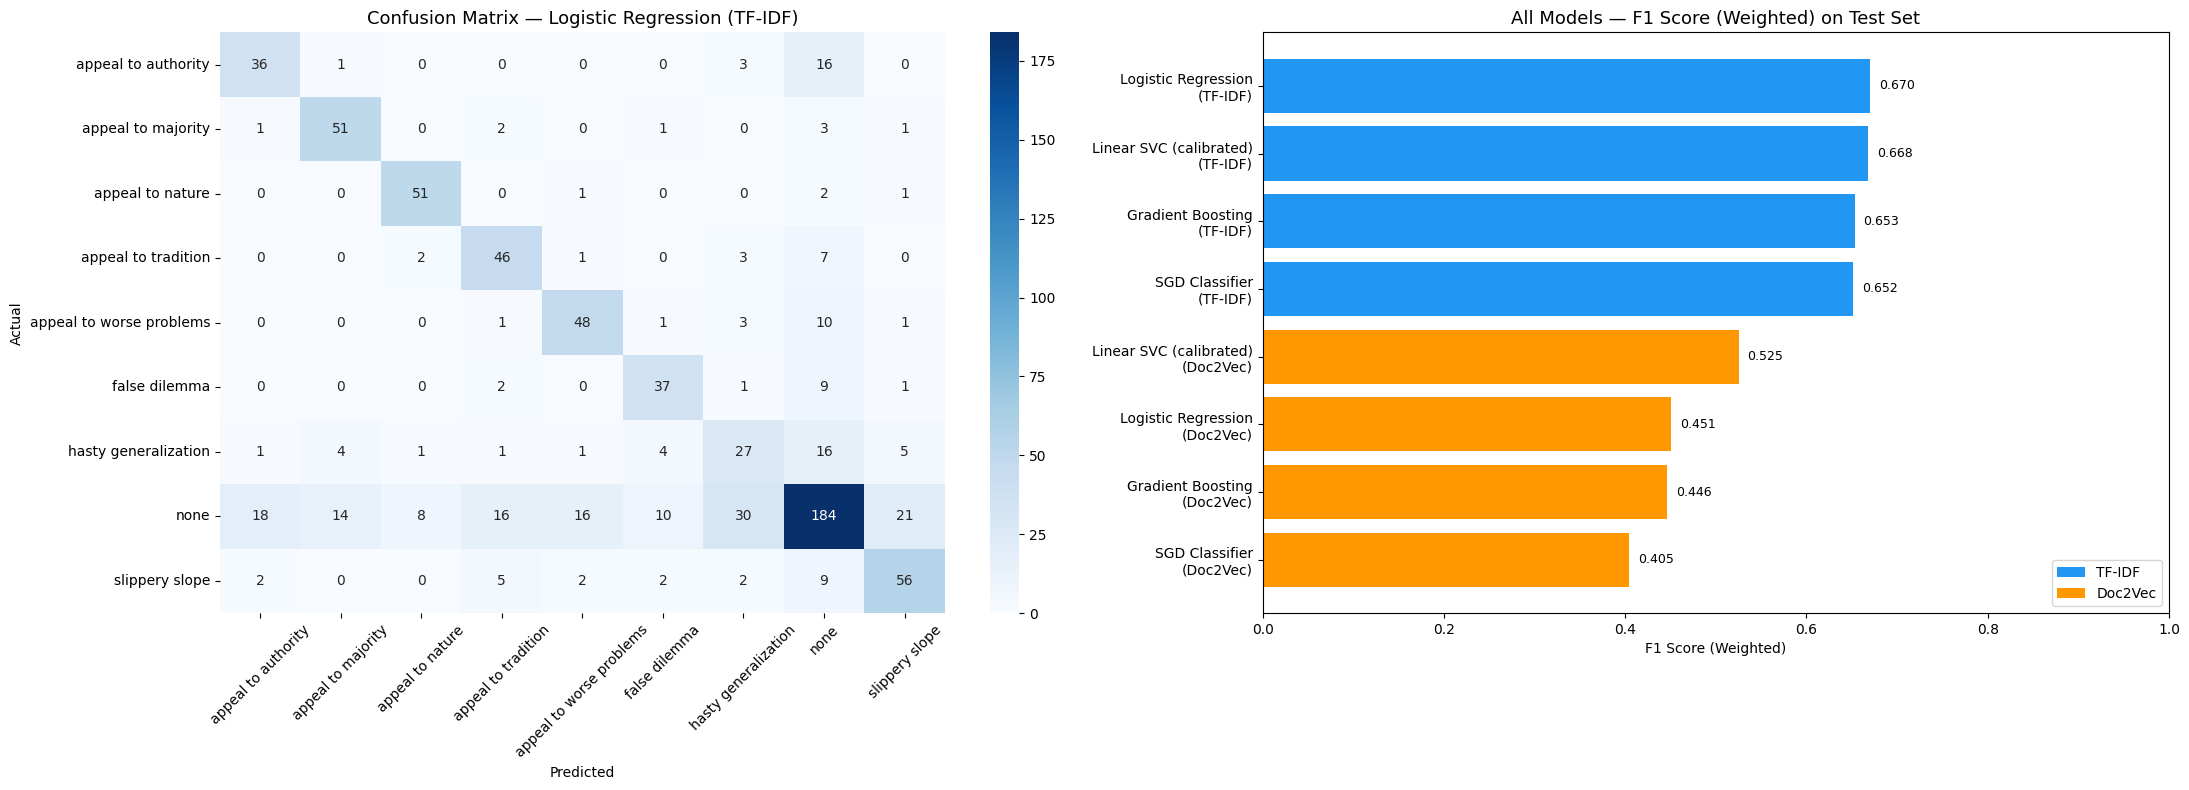

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# --- 1. Confusion Matrix (Best Model) ---
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {best_name} ({best_features})', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- 2. Model Comparison Bar Chart ---
plot_df = results_df.copy()
plot_df = plot_df.sort_values('F1 (weighted)', ascending=True)
plot_df['Label'] = plot_df['Model'] + '\n(' + plot_df['Features'] + ')'

colors = ['#2196F3' if f == 'TF-IDF' else '#FF9800' for f in plot_df['Features']]
axes[1].barh(plot_df['Label'], plot_df['F1 (weighted)'], color=colors)
axes[1].set_title('All Models — F1 Score (Weighted) on Test Set', fontsize=13)
axes[1].set_xlabel('F1 Score (Weighted)')
axes[1].set_xlim(0, 1)

# Add value labels
for i, (val, label) in enumerate(zip(plot_df['F1 (weighted)'], plot_df['Label'])):
    axes[1].text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='TF-IDF'),
                   Patch(facecolor='#FF9800', label='Word2Vec')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

### Per-Class F1-Score Breakdown

Menampilkan F1-Score per jenis fallacy untuk mengidentifikasi kelas mana yang paling sulit dideteksi.

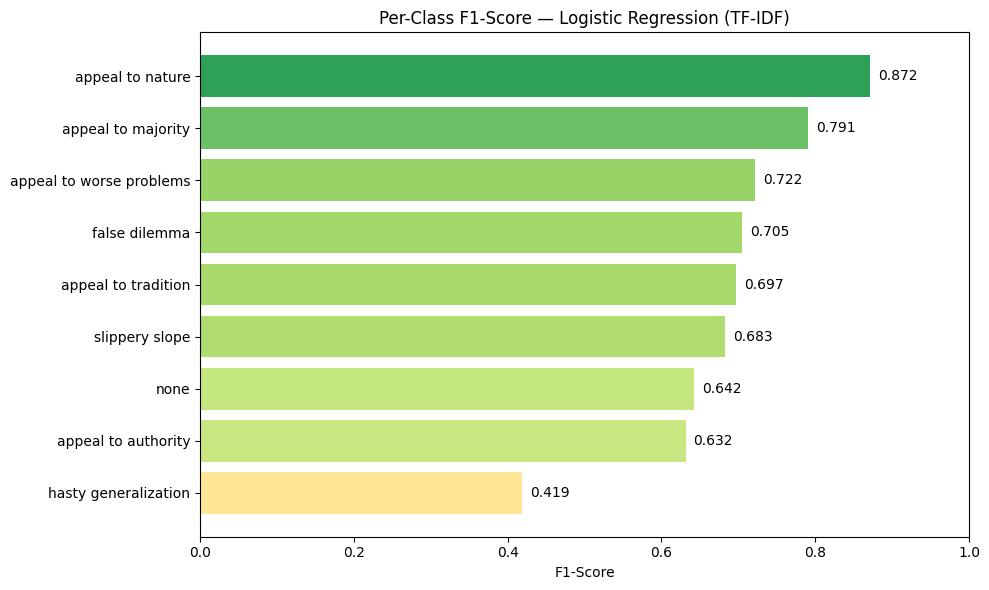


--- Per-Class Metrics (Logistic Regression, TF-IDF) ---


,Precision,Recall,F1-Score,Support
Fallacy Type,,,,
appeal to nature,0.8226,0.9273,0.8718,55
appeal to majority,0.7286,0.8644,0.7907,59
appeal to worse problems,0.6957,0.7500,0.7218,64
false dilemma,0.6727,0.7400,0.7048,50
appeal to tradition,0.6301,0.7797,0.6970,59
slippery slope,0.6512,0.7179,0.6829,78
none,0.7188,0.5804,0.6422,317
appeal to authority,0.6207,0.6429,0.6316,56
hasty generalization,0.3913,0.4500,0.4186,60


In [15]:
# Per-class F1 breakdown for best model
p_cls, r_cls, f1_cls, sup_cls = precision_recall_fscore_support(
    y_test, y_pred_best, labels=range(len(label_encoder.classes_))
)

class_df = pd.DataFrame({
    'Fallacy Type': label_encoder.classes_,
    'Precision': p_cls,
    'Recall': r_cls,
    'F1-Score': f1_cls,
    'Support': sup_cls.astype(int)
}).sort_values('F1-Score', ascending=True)

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(class_df['F1-Score'].values)
bars = ax.barh(class_df['Fallacy Type'], class_df['F1-Score'], color=colors)
ax.set_xlabel('F1-Score')
ax.set_title(f'Per-Class F1-Score — {best_name} ({best_features})')
ax.set_xlim(0, 1)

for bar, val in zip(bars, class_df['F1-Score'].values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# --- Table ---
print(f"\n--- Per-Class Metrics ({best_name}, {best_features}) ---")
class_df_display = class_df.sort_values('F1-Score', ascending=False).set_index('Fallacy Type')
class_df_display.style.format({
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'
}).background_gradient(subset=['F1-Score'], cmap='RdYlGn')

## 12. Save & Load Best Model

Menyimpan model terbaik, vectorizer, dan encoder ke disk agar bisa digunakan kembali tanpa training ulang.

In [ ]:
import joblib

SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Save best model ---
joblib.dump(best_model, os.path.join(SAVE_DIR, 'best_model.joblib'))
print(f"  Saved: {SAVE_DIR}/best_model.joblib  ({best_name}, {best_features})")

# --- Save vectorizers & encoder ---
joblib.dump(tfidf_vectorizer, os.path.join(SAVE_DIR, 'tfidf_vectorizer.joblib'))
print(f"  Saved: {SAVE_DIR}/tfidf_vectorizer.joblib")

w2v_model.save(os.path.join(SAVE_DIR, 'word2vec.model'))
print(f"  Saved: {SAVE_DIR}/word2vec.model")

joblib.dump(label_encoder, os.path.join(SAVE_DIR, 'label_encoder.joblib'))
print(f"  Saved: {SAVE_DIR}/label_encoder.joblib")

# --- Save metadata ---
joblib.dump({'best_name': best_name, 'best_features': best_features},
            os.path.join(SAVE_DIR, 'best_model_info.joblib'))
print(f"  Saved: {SAVE_DIR}/best_model_info.joblib")

print(f"\n✓ Best model + vectorizers + encoder saved to '{SAVE_DIR}/'")

  Saved: models/best_model.joblib  (Logistic Regression, TF-IDF)
  Saved: models/tfidf_vectorizer.joblib
  Saved: models/doc2vec.model
  Saved: models/label_encoder.joblib
  Saved: models/best_model_info.joblib

✓ Best model + vectorizers + encoder saved to 'models/'


In [ ]:
import joblib
from gensim.models import Word2Vec

SAVE_DIR = 'models'

if os.path.exists(os.path.join(SAVE_DIR, 'best_model_info.joblib')):
    # --- Load metadata ---
    best_info = joblib.load(os.path.join(SAVE_DIR, 'best_model_info.joblib'))
    best_name = best_info['best_name']
    best_features = best_info['best_features']

    # --- Load best model ---
    best_model = joblib.load(os.path.join(SAVE_DIR, 'best_model.joblib'))
    print(f"  Loaded: best_model — {best_name} ({best_features})")

    # --- Load vectorizers & encoder ---
    tfidf_vectorizer = joblib.load(os.path.join(SAVE_DIR, 'tfidf_vectorizer.joblib'))
    print(f"  Loaded: tfidf_vectorizer")

    w2v_model = Word2Vec.load(os.path.join(SAVE_DIR, 'word2vec.model'))
    print(f"  Loaded: word2vec model")

    label_encoder = joblib.load(os.path.join(SAVE_DIR, 'label_encoder.joblib'))
    print(f"  Loaded: label_encoder ({len(label_encoder.classes_)} classes)")

    print(f"\n✓ Saved models loaded — ready for prediction without retraining!")
else:
    print(f"⚠ No saved models found in '{SAVE_DIR}/'. Run the training + save cells first.")
    print("  (The models from the current session are still available if you trained them above.)")

  Loaded: best_model — Logistic Regression (TF-IDF)
  Loaded: tfidf_vectorizer
  Loaded: doc2vec model
  Loaded: label_encoder (9 classes)

✓ Saved models loaded — ready for prediction without retraining!


## 13. Predict New Input

Fungsi untuk memprediksi jenis logical fallacy dari sebuah teks baru. Menggunakan model dari `models/` (jika sudah di-load di Section 12) atau model dari sesi training saat ini.

In [ ]:
from scipy.special import softmax

def predict_fallacy(text, model=None, features=None, top_n=3):
    """
    Prediksi jenis logical fallacy dari sebuah teks komentar.
    
    Parameters:
        text (str): Teks komentar yang akan diprediksi
        model: Model sklearn (default: best model dari evaluasi)
        features (str): 'TF-IDF' atau 'Word2Vec' (default: sesuai best model)
        top_n (int): Jumlah prediksi teratas yang ditampilkan
    
    Returns:
        str: Label fallacy yang diprediksi
    """
    if model is None:
        model = best_model
        features = best_features
    
    # Preprocessing pipeline (same as training)
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    lemmatized = lemmatize_tokens(tokens)
    processed = ' '.join(lemmatized)
    
    # Feature extraction
    if 'tfidf' in features.lower() or 'tf-idf' in features.lower():
        X = tfidf_vectorizer.transform([processed])
    else:  # Word2Vec
        vec = document_vector(lemmatized, w2v_model)
        X = vec.reshape(1, -1)
    
    # Prediction
    prediction = model.predict(X)[0]
    predicted_label = label_encoder.inverse_transform([prediction])[0]
    
    # Display results
    print(f"  INPUT: \"{text[:100]}{'...' if len(text) > 100 else ''}\"")
    print(f"  Preprocessed : {processed[:80]}{'...' if len(processed) > 80 else ''}")
    print(f"  Token count  : {len(lemmatized)}")
    print(f"\n  → Predicted Fallacy: {predicted_label.upper()}")
    
    # Show confidence scores
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[0]
        top_indices = np.argsort(proba)[::-1][:top_n]
        print(f"\n  Top-{top_n} predictions:")
        for idx in top_indices:
            label = label_encoder.inverse_transform([idx])[0]
            bar = '█' * int(proba[idx] * 30)
            print(f"    {label:30s} {proba[idx]*100:5.1f}%  {bar}")
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X)[0]
        proba = softmax(scores)
        top_indices = np.argsort(proba)[::-1][:top_n]
        print(f"\n  Top-{top_n} predictions:")
        for idx in top_indices:
            label = label_encoder.inverse_transform([idx])[0]
            bar = '█' * int(proba[idx] * 30)
            print(f"    {label:30s} {proba[idx]*100:5.1f}%  {bar}")
    
    return predicted_label

print("✓ Fungsi predict_fallacy() siap digunakan.")

✓ Fungsi predict_fallacy() siap digunakan.


In [19]:
# Example inputs — written as realistic news comments (matching CoCoLoFa style)

test_texts = [
    # Slippery slope
    ("slippery slope",
     "If the government starts regulating social media content today, tomorrow they will censor independent journalists, then shut down opposition media, and before you know it we will be living in a totalitarian surveillance state with absolutely no free speech left."),
    # Appeal to authority
    ("appeal to authority",
     "According to Professor Johnson at MIT, this new climate policy is completely ineffective. He is one of the most respected researchers in this field so we should trust his judgment on this and reject the entire proposal without further debate."),
    # Appeal to majority
    ("appeal to majority",
     "A recent poll shows that 78 percent of Americans believe immigration is the biggest problem in the country right now. With so many people agreeing on this, it is clear that immigration must really be the single most important issue we face today."),
    # Appeal to tradition
    ("appeal to tradition",
     "Marriage has been between a man and a woman for thousands of years across every culture and civilization. Our ancestors understood this fundamental truth and we should respect the way things have always been done rather than trying to redefine something so sacred."),
    # Appeal to nature
    ("appeal to nature",
     "People should stop relying on pharmaceutical medications and switch to herbal remedies instead. Plants and natural substances are what nature intended for healing our bodies, so they must be inherently safer and more effective than synthetic chemicals made in a laboratory."),
    # False dilemma
    ("false dilemma",
     "When it comes to the conflict in the Middle East, you either support full military intervention to protect our allies or you are basically siding with the terrorists. There is simply no in-between position on this matter and anyone who claims otherwise is just being naive."),
    # Hasty generalization
    ("hasty generalization",
     "I read about three different cases of fraud committed by immigrants in the news this week. Clearly these people coming into our country cannot be trusted and are just looking to take advantage of our system. The evidence speaks for itself."),
    # Appeal to worse problems
    ("appeal to worse problems",
     "Why are activists complaining about gender pay gaps in Western countries when there are children literally starving to death in Africa every single day? We should focus on the real problems in the world before worrying about such trivial matters at home."),
    # None (neutral argument)
    ("none",
     "The proposed education reform has both advantages and disadvantages that deserve careful consideration. While it increases funding for rural schools, some critics raise valid concerns about the implementation timeline and oversight mechanisms. A thorough review of the available data from pilot programs would help clarify what adjustments might be needed."),
]

print("LOGICAL FALLACY PREDICTIONS (Best Model)")
print("=" * 70)
correct = 0
for expected, text in test_texts:
    result = predict_fallacy(text)
    match = '\u2713' if result == expected else '\u2717'
    if result == expected:
        correct += 1
    print(f"  Expected: {expected} | {match}")
    print()
print(f"{'=' * 70}")
print(f"Example Accuracy: {correct}/{len(test_texts)} ({correct/len(test_texts)*100:.0f}%)")

LOGICAL FALLACY PREDICTIONS (Best Model)
  INPUT: "If the government starts regulating social media content today, tomorrow they will censor independen..."
  Preprocessed : government start regulating social medium content today tomorrow censor independ...
  Token count  : 23

  → Predicted Fallacy: SLIPPERY SLOPE

  Top-3 predictions:
    slippery slope                  47.4%  ██████████████
    appeal to authority             13.2%  ███
    hasty generalization             8.4%  ██
  Expected: slippery slope | ✓

  INPUT: "According to Professor Johnson at MIT, this new climate policy is completely ineffective. He is one ..."
  Preprocessed : according professor johnson mit new climate policy completely ineffective one mo...
  Token count  : 22

  → Predicted Fallacy: APPEAL TO AUTHORITY

  Top-3 predictions:
    appeal to authority             50.4%  ███████████████
    appeal to majority               9.5%  ██
    none                             8.0%  ██
  Expected: appeal to auth

### Try Manual input

Ubah variabel `my_text` di bawah untuk menguji model dengan komentar kita sendiri.

In [20]:
my_text = "God must exist because the universe is so complex and beautiful that it couldn't have come about by chance. Only an intelligent designer could have created such a perfect world, so we should all believe in God to explain the mysteries of existence."

predict_fallacy(my_text)

  INPUT: "God must exist because the universe is so complex and beautiful that it couldn't have come about by ..."
  Preprocessed : god must exist universe complex beautiful couldnt come chance only intelligent d...
  Token count  : 23

  → Predicted Fallacy: NONE

  Top-3 predictions:
    none                            28.5%  ████████
    slippery slope                  12.1%  ███
    false dilemma                   11.3%  ███


'none'